In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## 1:Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

### 2: Load local CSV

In [2]:
# Load Dataset

df = pd.read_csv("/kaggle/input/test-file/tested.csv")

# Display first 5 rows
df.head(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


### 3:Data type of columns

In [3]:
# viewing the data types of columns
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

### 4:Check missing values

In [4]:
print(df.isna().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


### 5:Check duplicate rows

In [5]:
# checking duplicate rows
df.duplicated()[df.duplicated()==True]

Series([], dtype: bool)

### 6:No. of rows and columns

In [6]:
# finding number of rows and columns
print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (418, 12) 

number of rows:  418
number of columns:  12


### 7:Descriptive summary Statistics

In [7]:
# Statistical summary
df.describe(include='all')

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,418.000000,418.000000,418.000000,418,418,332.000000,418.000000,418.000000,418,417.000000,91,418
unique,NaN,NaN,NaN,418,2,NaN,NaN,NaN,363,NaN,76,3
top,NaN,NaN,NaN,"Peter, Master. Michael J",male,NaN,NaN,NaN,PC 17608,NaN,B57 B59 B63 B66,S
freq,NaN,NaN,NaN,1,266,NaN,NaN,NaN,5,NaN,3,270
mean,1100.500000,0.363636,2.265550,NaN,NaN,30.272590,0.447368,0.392344,NaN,35.627188,NaN,NaN
std,120.810458,0.481622,0.841838,NaN,NaN,14.181209,0.896760,0.981429,NaN,55.907576,NaN,NaN
min,892.000000,0.000000,1.000000,NaN,NaN,0.170000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,996.250000,0.000000,1.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN
50%,1100.500000,0.000000,3.000000,NaN,NaN,27.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,1204.750000,1.000000,3.000000,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.500000,NaN,NaN


### 8:Univariate Analysis

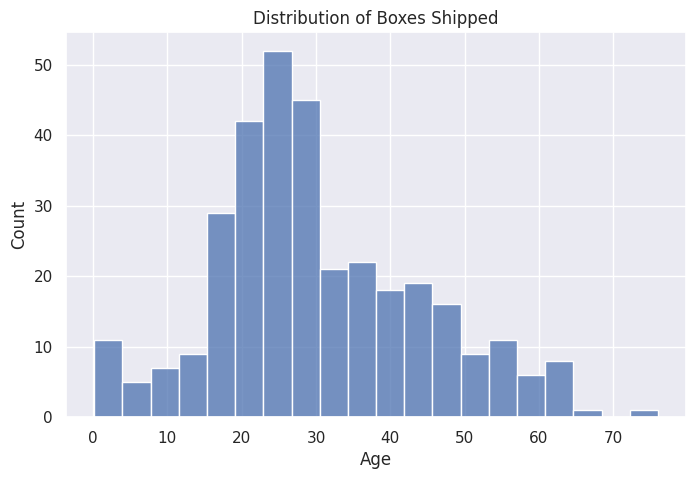

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['Age'], bins=20)
plt.title("Distribution of Boxes Shipped")
plt.show()

### 9:Distribution of Fare

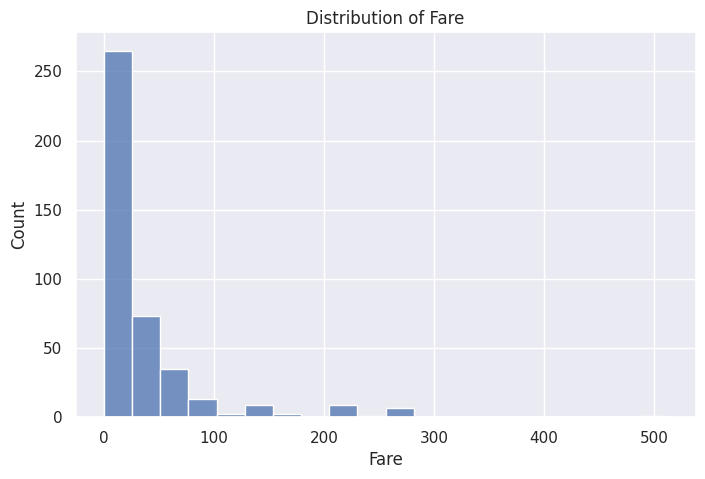

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df['Fare'], bins=20)
plt.title("Distribution of Fare")
plt.show()

## Bivariate Analysis

### 10:Fare by Gender

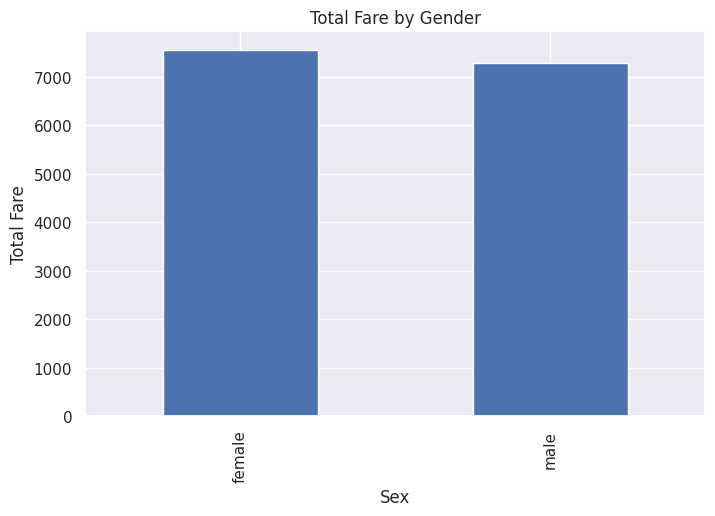

Sex
female    7561.6502
male      7294.8874
Name: Fare, dtype: float64

In [10]:
gender_fare = df.groupby('Sex')['Fare'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
gender_fare.plot(kind='bar')
plt.title("Total Fare by Gender")
plt.ylabel("Total Fare")
plt.show()

gender_fare

### 11:Fare by Embarkation Port

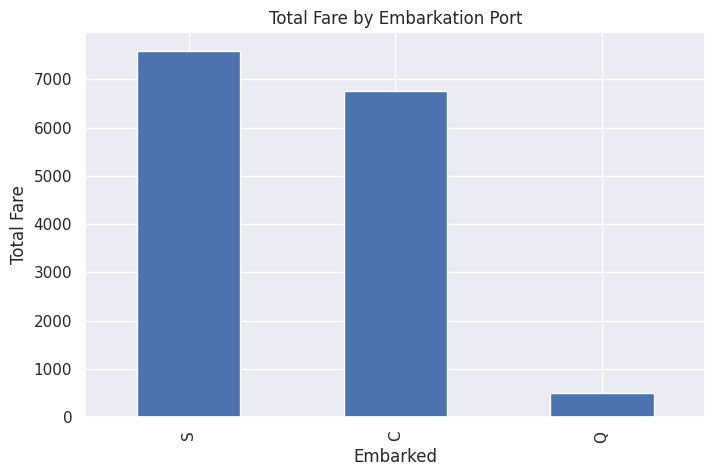

Embarked
S    7593.9874
C    6758.4960
Q     504.0542
Name: Fare, dtype: float64

In [11]:
port_fare = df.groupby('Embarked')['Fare'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
port_fare.plot(kind='bar')
plt.title("Total Fare by Embarkation Port")
plt.ylabel("Total Fare")
plt.show()

port_fare

### 12:fare by Gender

In [12]:
gender_fare = df.groupby('Sex')['Fare'].sum().sort_values(ascending=False)

gender_fare.head(10)


Sex
female    7561.6502
male      7294.8874
Name: Fare, dtype: float64

## 13:Age vs Fare Reletionship

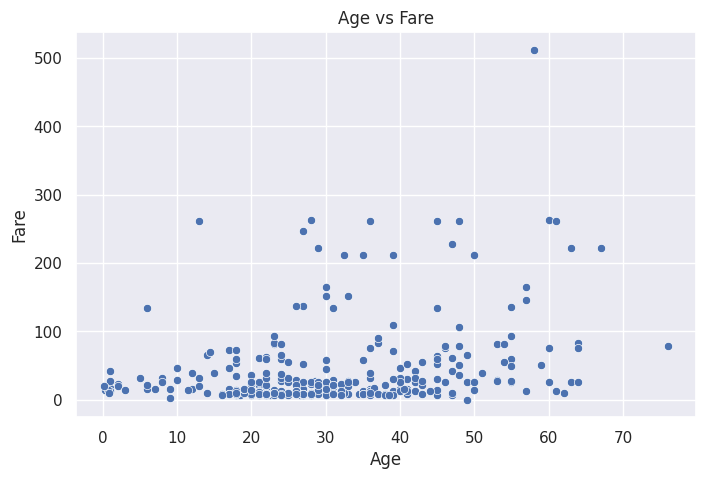

In [13]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='Fare', data=df)
plt.title("Age vs Fare")
plt.show()

## 14:Correlation Matrix

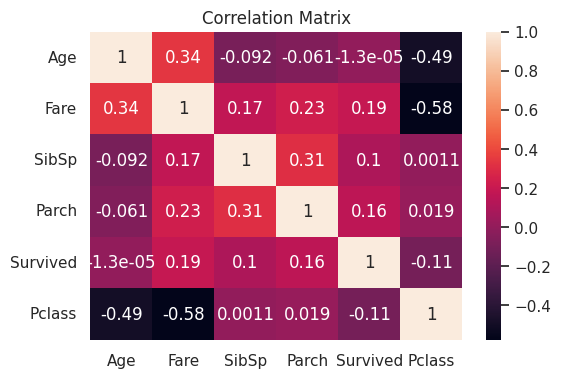

In [14]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Age','Fare','SibSp','Parch','Survived','Pclass']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

## Time-Based Analysis
### 15:Average Fare by Passenger Class

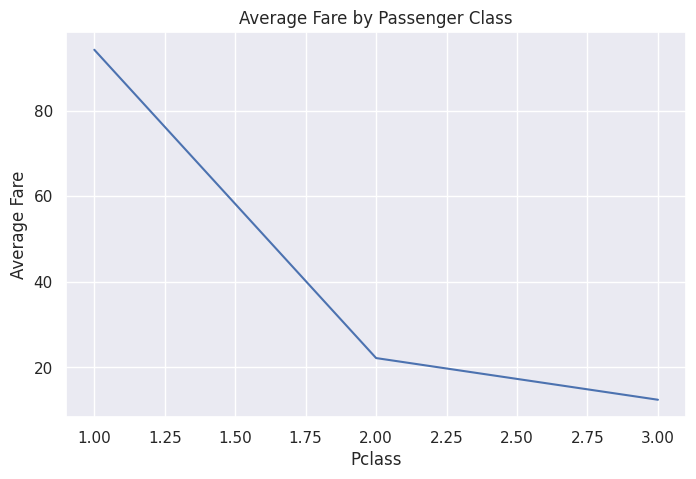

In [15]:
avg_fare_class = df.groupby('Pclass')['Fare'].mean()

plt.figure(figsize=(8,5))
avg_fare_class.plot()
plt.title("Average Fare by Passenger Class")
plt.ylabel("Average Fare")
plt.show()